# Import Libraries

Import the libraries required for data analysis and visualization in order to investigate the distribution of claim types in sustainability reports.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Master Dataset

Load the master dataset generated during the preprocessing stage. This dataset contains the merged sustainability reports, ESG information, and generated claim features.

In [9]:
merged = pd.read_csv("Master_Dataset.csv")

# Remove unnecessary index column if it exists
if "Unnamed: 0" in merged.columns:
    merged = merged.drop(columns=["Unnamed: 0"])

print(merged.head())

           filename ticker  year  \
0  ASX_BSX_2020.pdf    BSX  2020   
1  ASX_BSX_2022.pdf    BSX  2022   
2  ASX_EXR_2022.pdf    EXR  2022   
3  LSE_ADM_2019.pdf    ADM  2019   
4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'mongolia', 'australia', 'austra...     3.81     4.28   
3  ['david stevens', 'csr board', 'just over  yea...    16.38    14.20   
4  ['year', 'health & wellbeing', 'a -month', 'on...    15.89    13.51   

 

# Create Claim Type Distribution Table

Compute the frequency of each claim category to understand the distribution of concrete, vague, and unverifiable sustainability claims.

In [10]:
rq1_table = merged['claim_type'].value_counts().reset_index()

rq1_table.columns = ['Claim_Type', 'Count']

rq1_table['Percentage'] = (
    rq1_table['Count'] /
    rq1_table['Count'].sum()
) * 100

rq1_table['Percentage'] = rq1_table['Percentage'].round(2)

print(rq1_table)

rq1_table.to_csv(
    "RQ1_Claim_Type_Distribution.csv",
    index=False
)

  Claim_Type  Count  Percentage
0      Vague    753       87.35
1   Concrete    109       12.65


# Visualize Claim Type Distribution

Generate a visual representation of the claim type distribution to facilitate interpretation and comparison of the identified claim categories.

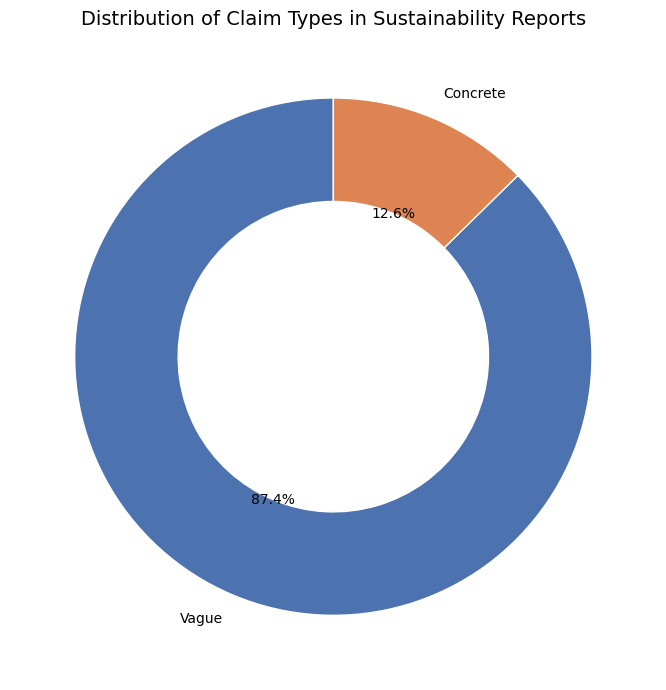

In [15]:
# Donut chart for claim type distribution
plt.figure(figsize=(7,7))

colors = ['#4C72B0', '#DD8452']

plt.pie(
    rq1_table['Count'],
    labels=rq1_table['Claim_Type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

plt.title(
    "Distribution of Claim Types in Sustainability Reports",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "RQ1_Claim_Type_Donut_Chart.pdf",
    bbox_inches='tight'
)

plt.show()

# Save Figure and Table

The generated table and figure were automatically saved for subsequent use in the report, poster presentation, and comparative analyses.

In [16]:
# Save table
rq1_table.to_csv(
    "RQ1_Claim_Type_Distribution.csv",
    index=False
)

# Save donut chart
plt.savefig(
    "RQ1_Claim_Type_Donut_Chart.pdf",
    bbox_inches='tight'
)

print("RQ1 outputs saved successfully.")

RQ1 outputs saved successfully.


<Figure size 640x480 with 0 Axes>